FUNCIÓN 1
f(x)=1/(25x²+1)

Taylor orden 2
1 - 25*x**2

Taylor orden 4
625*x**4 - 25*x**2 + 1

Taylor orden 6
-15625*x**6 + 625*x**4 - 25*x**2 + 1

Polinomio de Lagrange
62.5*x**4 + 1.77635683940025e-15*x**3 - 15.0*x**2 + 1.0


FUNCIÓN 2
f(x)=arctan(x)

Taylor orden 2
-x**2/4 + x - 3/4 + pi/4

Taylor orden 4
x**3/12 - x**2/2 + 5*x/4 - 5/6 + pi/4

Polinomio de Lagrange
0.00644628452599605*x**4 + 0.0490818629114784*x**3 - 0.436244856115536*x**2 + 1.1998883493852*x - 0.0337734773097189


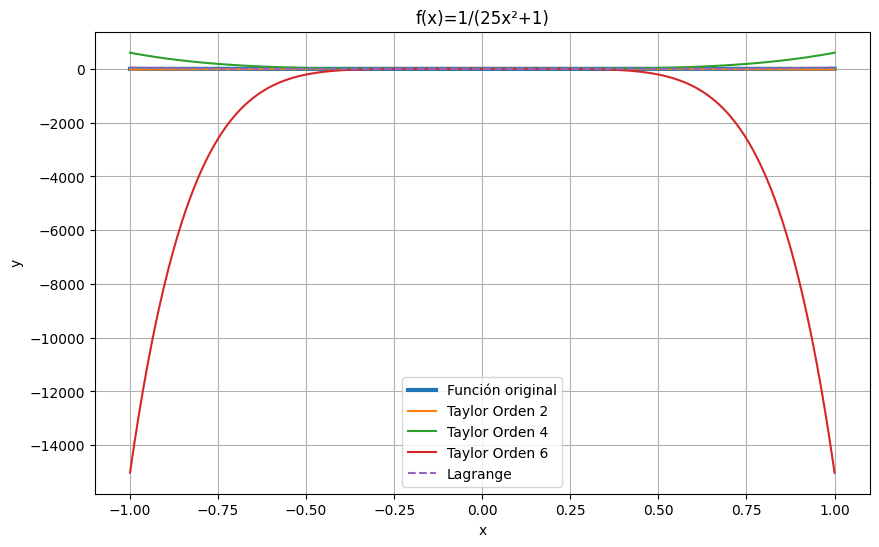

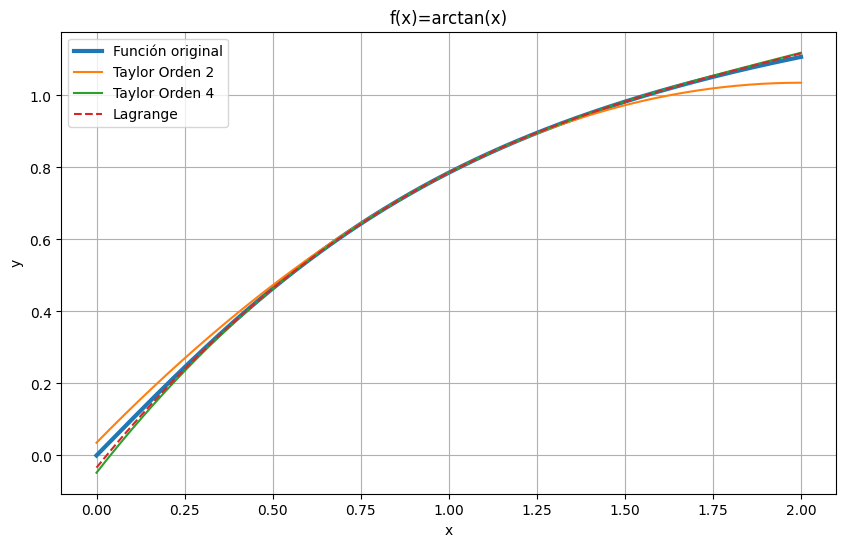

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
x = sp.Symbol('x')

# FUNCIÓN 1
# f(x)=1/(25x²+1)
# Taylor en x0=0

f1 = 1/(25*x**2 + 1)

print("FUNCIÓN 1")
print("f(x)=1/(25x²+1)")


# Taylor

T2 = sp.series(f1, x, 0, 3).removeO()
T4 = sp.series(f1, x, 0, 5).removeO()
T6 = sp.series(f1, x, 0, 7).removeO()

print("\nTaylor orden 2")
print(sp.expand(T2))

print("\nTaylor orden 4")
print(sp.expand(T4))

print("\nTaylor orden 6")
print(sp.expand(T6))

# Lagrange

puntos1 = [
(-0.4, float(f1.subs(x,-0.4))),
(-0.2, float(f1.subs(x,-0.2))),
(0.0, float(f1.subs(x,0))),
(0.2, float(f1.subs(x,0.2))),
(0.4, float(f1.subs(x,0.4)))
]

L1 = sp.interpolate(puntos1,x)

print("\nPolinomio de Lagrange")
print(sp.expand(L1))

# FUNCIÓN 2
# arctan(x)
# Taylor en x0=1

f2 = sp.atan(x)

print("\n")
print("FUNCIÓN 2")
print("f(x)=arctan(x)")

T2_f2 = sp.series(f2,x,1,3).removeO()
T4_f2 = sp.series(f2,x,1,5).removeO()

print("\nTaylor orden 2")
print(sp.expand(T2_f2))

print("\nTaylor orden 4")
print(sp.expand(T4_f2))

# Lagrange

puntos2 = [
(0.5,float(f2.subs(x,0.5))),
(0.75,float(f2.subs(x,0.75))),
(1.0,float(f2.subs(x,1))),
(1.25,float(f2.subs(x,1.25))),
(1.5,float(f2.subs(x,1.5)))
]

L2 = sp.interpolate(puntos2,x)

print("\nPolinomio de Lagrange")
print(sp.expand(L2))


f1_real = sp.lambdify(x,f1,"numpy")
f2_real = sp.lambdify(x,f2,"numpy")

t2 = sp.lambdify(x,T2,"numpy")
t4 = sp.lambdify(x,T4,"numpy")
t6 = sp.lambdify(x,T6,"numpy")
lag1 = sp.lambdify(x,L1,"numpy")

t2f2 = sp.lambdify(x,T2_f2,"numpy")
t4f2 = sp.lambdify(x,T4_f2,"numpy")
lag2 = sp.lambdify(x,L2,"numpy")

X = np.linspace(-1,1,500)

plt.figure(figsize=(10,6))
plt.plot(X,f1_real(X),label="Función original",linewidth=3)
plt.plot(X,t2(X),label="Taylor Orden 2")
plt.plot(X,t4(X),label="Taylor Orden 4")
plt.plot(X,t6(X),label="Taylor Orden 6")
plt.plot(X,lag1(X),label="Lagrange",linestyle="--")
plt.title("f(x)=1/(25x²+1)")
plt.xlabel("x")
plt.ylabel("y")

plt.grid(True)

plt.legend()

X2 = np.linspace(0,2,500)

plt.figure(figsize=(10,6))

plt.plot(X2,f2_real(X2),label="Función original",linewidth=3)

plt.plot(X2,t2f2(X2),label="Taylor Orden 2")

plt.plot(X2,t4f2(X2),label="Taylor Orden 4")

plt.plot(X2,lag2(X2),label="Lagrange",linestyle="--")

plt.title("f(x)=arctan(x)")

plt.xlabel("x")

plt.ylabel("y")

plt.grid(True)

plt.legend()

plt.show()